# Notebook 01 — pandas Fundamentals with Market Data

**FIN 4600 · Lab 3 · Financial Data Analytics**

Duran, *Financial Services Technology* (3rd ed.), **Chapter 6 — Data Analytics**

---

Chapter 6 makes the point that analytics is mostly *data management*: the
modelling is the last and smallest step. This notebook is the data-management
step. By the end of it you will be able to load a raw market data file,
inspect it, reshape it, aggregate it, join reference data onto it, and handle
the gaps — which is roughly 80% of what a financial data analyst does.

**What you will learn**

| Skill | Why a finance professional needs it |
|---|---|
| `read_csv`, dtypes, dates | Vendor files arrive as text; a date stored as text cannot be sorted or differenced |
| `.loc` / `.iloc` / boolean masks | Selecting the rows a risk report actually covers |
| `groupby` | Per-desk, per-instrument, per-sector aggregation |
| `pivot` (long ↔ wide) | Market data arrives long; portfolio maths needs wide |
| `resample` | Daily marks → month-end reporting periods |
| `merge` | Attaching reference/security-master data to transactions |
| Missing-data handling | Holidays, halts, delistings, late feeds |

**Datasets used**

- `data/sp500_prices.csv` — real daily OHLCV for 30 large-cap US stocks,
  Feb 2013 – Feb 2018
- `data/sp500_companies.csv` — a security master: ticker, company name, GICS sector

## 0. Setup

Every notebook starts with this same block. It finds the repository, points at
the `data` folder, and loads the shared chart style.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=None):
    """Return the repository root — the folder that contains data/sp500_prices.csv."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "sp500_prices.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root. In VS Code use File > Open Folder "
        "and open the mtu4600-lab3-analytics folder itself, then re-run."
    )


REPO = find_repo_root()
DATA = REPO / "data"
plt.style.use(REPO / "fin4600.mplstyle")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

print("Repository root:", REPO)

Repository root: /Users/sabrinaloftus/mtu4600-lab3-analytics


## 1. Loading a file — and why `parse_dates` matters

First, deliberately load the file the *wrong* way, so you can see what goes
wrong. This is the single most common bug in student market-data code.

In [5]:
wrong = pd.read_csv(DATA / "sp500_prices.csv")
print("dtype of the date column when we don't say anything:", wrong["date"].dtype)
print("\nSorting a text date is alphabetical, not chronological, which is fine")
print("for ISO dates but silently wrong for formats like 3/9/2015 vs 12/1/2014.")
print("\nAnd you cannot do arithmetic on it:")
try:
    wrong["date"].max() - wrong["date"].min()
except TypeError as exc:
    print("   TypeError:", exc)

dtype of the date column when we don't say anything: str

Sorting a text date is alphabetical, not chronological, which is fine
for ISO dates but silently wrong for formats like 3/9/2015 vs 12/1/2014.

And you cannot do arithmetic on it:
   TypeError: unsupported operand type(s) for -: 'str' and 'str'


Now load it properly. `parse_dates` converts the column to pandas'
`datetime64` type, which knows about calendars, ordering, and differences.

In [6]:
prices = pd.read_csv(DATA / "sp500_prices.csv", parse_dates=["date"])

print("dtype of the date column now:", prices["date"].dtype)
print("Span of the data:", prices["date"].max() - prices["date"].min())
prices.head()

dtype of the date column now: datetime64[us]
Span of the data: 1825 days 00:00:00


,date,ticker,open,high,low,close,volume
0,2013-02-08,AAPL,67.7142,68.4014,66.8928,67.8542,158168416
1,2013-02-11,AAPL,68.0714,69.2771,67.6071,68.5614,129029425
2,2013-02-12,AAPL,68.5014,68.9114,66.8205,66.8428,151829363
3,2013-02-13,AAPL,66.7442,67.6628,66.1742,66.7156,118721995
4,2013-02-14,AAPL,66.3599,67.3771,66.2885,66.6556,88809154


## 2. First look: shape, dtypes, describe

Before any analysis, answer three questions: *How big is it? What types are
the columns? Do the numbers look plausible?*

In [7]:
print("Rows and columns:", prices.shape)
print()
prices.info()

Rows and columns: (37770, 7)

<class 'pandas.DataFrame'>
RangeIndex: 37770 entries, 0 to 37769
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    37770 non-null  datetime64[us]
 1   ticker  37770 non-null  str           
 2   open    37770 non-null  float64       
 3   high    37770 non-null  float64       
 4   low     37770 non-null  float64       
 5   close   37770 non-null  float64       
 6   volume  37770 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 2.0 MB


`describe()` gives the five-number summary of every numeric column. Read it
sceptically — this is where you catch negative prices, zero volumes, and
prices that are off by a factor of 100 because someone stored cents.

In [8]:
prices.describe()

,date,open,high,low,close,volume
count,37770,37770.000000,37770.000000,37770.000000,37770.000000,3.777000e+04
mean,2015-08-09 05:44:16.393963,101.875792,102.622688,101.114023,101.899438,1.667327e+07
min,2013-02-08 00:00:00,11.120000,11.220000,10.980000,11.030000,4.870170e+05
25%,2014-05-09 00:00:00,43.450000,43.730000,43.190000,43.490000,3.914933e+06
50%,2015-08-10 00:00:00,79.770000,80.280000,79.254950,79.810000,8.291398e+06
75%,2016-11-07 00:00:00,112.250000,113.152500,111.337500,112.280000,2.014227e+07
max,2018-02-07 00:00:00,1188.000000,1198.000000,1184.060000,1187.560000,6.182376e+08
std,NaN,122.210705,123.097389,121.223113,122.204396,2.397416e+07


## 3. Selecting rows and columns

Three tools, and it is worth being clear about when to use each:

- `df["col"]` — one column, by name
- `df.loc[rows, cols]` — select by **label** (a ticker, a date, a column name)
- `df.iloc[rows, cols]` — select by **integer position** (row 0, row 5)

In practice, `.loc` with a boolean mask is what you will use 90% of the time.

In [9]:
# A single column is a Series
print(type(prices["close"]))

# A list of columns is a DataFrame
prices[["date", "ticker", "close"]].head(3)

<class 'pandas.Series'>


,date,ticker,close
0,2013-02-08,AAPL,67.8542
1,2013-02-11,AAPL,68.5614
2,2013-02-12,AAPL,66.8428


In [10]:
# Boolean mask: one bank's rows only
jpm = prices.loc[prices["ticker"] == "JPM"]
print("JPM rows:", len(jpm))

# Two conditions. Note the parentheses — & and | bind tighter than == in Python,
# so leaving the parentheses out is a syntax error.
big_down_days = prices.loc[
    (prices["ticker"] == "JPM") & (prices["close"] < prices["open"] * 0.97)
]
print("JPM days that closed more than 3% below the open:", len(big_down_days))
big_down_days[["date", "open", "close", "volume"]]

JPM rows: 1259
JPM days that closed more than 3% below the open: 8


,date,open,close,volume
19179,2014-04-10,59.35,57.40,29977179
19380,2015-01-28,56.62,54.75,24354354
19525,2015-08-25,63.10,59.91,31772532
19619,2016-01-08,61.13,58.92,22373287
19622,2016-01-13,59.46,57.34,28808129
19649,2016-02-23,57.90,56.12,31772544
19920,2017-03-21,90.36,87.39,33089241
20141,2018-02-05,113.00,108.80,30097591


In [11]:
# .isin() for a set of labels
banks = prices.loc[prices["ticker"].isin(["JPM", "GS", "BAC", "WFC"])]
print("Bank rows:", len(banks), "across", banks["ticker"].nunique(), "tickers")

Bank rows: 5036 across 4 tickers


### Exercise 1

Select every row for `XOM` (Exxon) in calendar year 2015 where daily volume
was above 20 million shares. How many such days were there?

*Hint:* `prices["date"].dt.year` gives the year of a datetime column.

In [15]:
# YOUR CODE HERE
Exxonnn = prices.loc[(prices["ticker"] == "XOM") & (prices["date"] >= "2015-01-01") & (prices["date"] <= "2015-12-31") & (prices["volume"] > 20000000)]
print("Exxon rows:", len(Exxonnn))

Exxon rows: 24


## 4. Adding computed columns

Never write a Python loop over rows. pandas operations are *vectorised* —
they apply to the whole column at once, in compiled code. On this dataset the
difference is roughly a hundredfold, and on a real tick file it is the
difference between a report that runs and one that does not.

In [16]:
prices["daily_range_pct"] = (prices["high"] - prices["low"]) / prices["close"] * 100
prices["dollar_volume"] = prices["close"] * prices["volume"]
prices["year"] = prices["date"].dt.year

prices[["date", "ticker", "close", "daily_range_pct", "dollar_volume", "year"]].head()

,date,ticker,close,daily_range_pct,dollar_volume,year
0,2013-02-08,AAPL,67.8542,2.223296,1.073239e+10,2013
1,2013-02-11,AAPL,68.5614,2.435773,8.846438e+09,2013
2,2013-02-12,AAPL,66.8428,3.128086,1.014870e+10,2013
3,2013-02-13,AAPL,66.7156,2.231262,7.920609e+09,2013
4,2013-02-14,AAPL,66.6556,1.633171,5.919627e+09,2013


## 5. `groupby` — the workhorse

"Split, apply, combine". Split the rows into groups, apply a function to each
group, combine the answers into one table. Every per-desk, per-sector, or
per-instrument report you will ever build is a `groupby`.

In [17]:
# One statistic per ticker
by_ticker = prices.groupby("ticker")["close"].mean().sort_values(ascending=False)
by_ticker.head(8)

ticker
GOOGL    682.233847
GS       187.528459
MMM      160.306330
BA       149.905989
UNH      121.003257
HD       114.972844
MCD      114.196267
CVX      109.969000
Name: close, dtype: float64

In [18]:
# Several statistics at once, with readable output column names
summary = prices.groupby("ticker").agg(
    first_close=("close", "first"),
    last_close=("close", "last"),
    avg_daily_range_pct=("daily_range_pct", "mean"),
    avg_dollar_volume_mm=("dollar_volume", lambda s: s.mean() / 1e6),
    n_days=("close", "size"),
)
summary["total_return_pct"] = (
    summary["last_close"] / summary["first_close"] - 1
) * 100

summary.sort_values("total_return_pct", ascending=False).round(2).head(10)

,first_close,last_close,avg_daily_range_pct,avg_dollar_volume_mm,n_days,total_return_pct
ticker,,,,,,
BA,76.56,348.12,1.61,614.67,1259,354.70
UNH,57.74,225.82,1.68,456.93,1259,291.10
MSFT,27.55,89.61,1.62,1623.28,1259,225.26
HD,67.01,191.29,1.46,616.43,1259,185.46
GOOGL,393.08,1055.41,1.58,1550.02,1259,168.50
BAC,11.76,31.25,1.89,1606.71,1259,165.73
NKE,27.30,65.63,1.61,417.24,1259,140.45
AAPL,67.85,159.54,1.71,5260.97,1259,135.12
JPM,48.63,112.87,1.57,1093.38,1259,132.10


In [ ]:
# Group by two keys — the result has a MultiIndex
by_ticker_year = prices.groupby(["ticker", "year"])["dollar_volume"].mean()
by_ticker_year.head(6)

ticker  year
AAPL    2013    6.359868e+09
        2014    5.680047e+09
        2015    6.192152e+09
        2016    3.983118e+09
        2017    4.078207e+09
        2018    6.425322e+09
Name: dollar_volume, dtype: float64

### Exercise 2

Which three tickers had the **highest average daily range** (`daily_range_pct`)
over the whole period? Does the answer match your intuition about which of
these businesses is riskiest?

In [45]:
# YOUR CODE HERE
summary.sort_values("avg_daily_range_pct", ascending=False).round(2).head(3)
# This does not meet my expectations for what businesses would be the riskiest.  I would expect 
# for tech and AI to show the highest volatility in price.

,first_close,last_close,avg_daily_range_pct,avg_dollar_volume_mm,n_days,total_return_pct
ticker,,,,,,
BAC,11.76,31.25,1.89,1606.71,1259,165.73
GS,151.60,257.10,1.73,606.18,1259,69.59
CAT,96.85,154.34,1.73,489.82,1259,59.36


## 6. Long vs wide: `pivot`

The file is in **long** format — one row per ticker per day. That is how
market data is stored and transmitted, because it handles instruments with
different histories cleanly.

Portfolio mathematics needs **wide** format — one row per day, one column per
ticker. Correlation matrices, covariance matrices and portfolio returns all
assume a wide matrix. Converting between the two is a daily task.

In [46]:
close_wide = prices.pivot(index="date", columns="ticker", values="close")

print("Long format:", prices.shape)
print("Wide format:", close_wide.shape)
close_wide.iloc[:5, :6]

Long format: (37770, 10)
Wide format: (1259, 30)


ticker,AAPL,AMT,BA,BAC,CAT,CSCO
date,,,,,,
2013-02-08,67.8542,77.06,76.56,11.760,96.85,21.16
2013-02-11,68.5614,76.38,75.87,11.860,96.60,21.27
2013-02-12,66.8428,75.59,75.99,12.245,97.22,20.97
2013-02-13,66.7156,74.00,74.78,12.170,96.38,21.14
2013-02-14,66.6556,73.48,74.93,12.130,96.07,20.99


In [47]:
# ...and back again, which you need when writing to a database
back_to_long = close_wide.stack().rename("close").reset_index()
back_to_long.head(3)

,date,ticker,close
0,2013-02-08,AAPL,67.8542
1,2013-02-08,AMT,77.0600
2,2013-02-08,BA,76.5600


## 7. `resample` — changing the time frequency

Daily marks, month-end reporting. `resample` only works on a datetime index,
which is why we pivoted first.

The rule strings you will use most: `"ME"` month-end, `"QE"` quarter-end,
`"YE"` year-end, `"W"` weekly.

In [48]:
monthly_close = close_wide.resample("ME").last()
print("Daily observations:", len(close_wide))
print("Monthly observations:", len(monthly_close))
monthly_close.iloc[:5, :6].round(2)

Daily observations: 1259
Monthly observations: 61


ticker,AAPL,AMT,BA,BAC,CAT,CSCO
date,,,,,,
2013-02-28,63.06,77.60,76.90,11.23,92.37,20.86
2013-03-31,63.24,76.92,85.85,12.18,86.97,20.90
2013-04-30,63.25,83.99,91.41,12.31,84.67,20.92
2013-05-31,64.25,77.84,99.02,13.66,85.80,24.12
2013-06-30,56.65,73.17,102.44,12.86,82.49,24.34


In [49]:
# Different columns often want different rules. Volume sums; price takes the last.
aapl_daily = prices.loc[prices["ticker"] == "AAPL"].set_index("date")
aapl_monthly = aapl_daily.resample("ME").agg(
    open=("open", "first"),
    high=("high", "max"),
    low=("low", "min"),
    close=("close", "last"),
    volume=("volume", "sum"),
)
aapl_monthly.head().round(2)

,open,high,low,close,volume
date,,,,,
2013-02-28,67.71,69.28,62.52,63.06,1611612359
2013-03-31,62.57,67.14,59.86,63.24,2288916525
2013-04-30,63.13,63.61,55.01,63.25,2733426556
2013-05-31,63.49,66.54,59.84,64.25,2359987959
2013-06-30,64.39,64.92,55.55,56.65,1753831331


## 8. Joining reference data: `merge`

Prices alone cannot answer "how did Financials do?". For that you need a
**security master** — the reference table that maps an instrument identifier
to its attributes. Every bank has one, and keeping it correct is a permanent
operational headache.

In [50]:
companies = pd.read_csv(DATA / "sp500_companies.csv")
print("Security master rows:", len(companies))
companies.head()

Security master rows: 100


,ticker,company,sector,sub_industry,headquarters,date_added,cik
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,"Santa Clara, California",2000-06-05,1090872
1,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals","Cupertino, California",1982-11-30,320193
2,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152
3,ABNB,Airbnb,Consumer Discretionary,"Hotels, Resorts & Cruise Lines","San Francisco, California",2023-09-18,1559720
4,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800


### The join that quietly loses rows

An **inner** join keeps only rows that match on both sides. A **left** join
keeps every price row and leaves `NaN` where the master has no entry.

In production you almost always want a left join *plus an alert*, because a
silent inner join is how a position disappears from a risk report.

In [51]:
inner = prices.merge(companies, on="ticker", how="inner")
left = prices.merge(companies, on="ticker", how="left")

print("Price rows before the join:", len(prices))
print("After an inner join:       ", len(inner))
print("After a left join:         ", len(left))

unmatched = left.loc[left["sector"].isna(), "ticker"].unique()
print("\nTickers with no security-master entry:", list(unmatched) or "none")

Price rows before the join: 37770
After an inner join:        37770
After a left join:          37770

Tickers with no security-master entry: none


Here every ticker matched. That is because the file was curated for this lab.
Reality is messier: the security master is a *current* index membership list,
while the price history covers 2013–2018, so a real join of the full files
would strand every company that has since been acquired or removed. Let's
simulate that, because recognising the symptom is the skill.

In [52]:
# Pretend the security master lost three entries, as if those firms were acquired
damaged = companies.loc[~companies["ticker"].isin(["GE", "T", "DUK"])]

risky_inner = prices.merge(damaged, on="ticker", how="inner")
safe_left = prices.merge(damaged, on="ticker", how="left")

print(f"Inner join silently dropped {len(prices) - len(risky_inner):,} rows.")
print("Left join kept them all and flagged the problem:")
print("   unmatched tickers:", sorted(safe_left.loc[safe_left['sector'].isna(), 'ticker'].unique()))

Inner join silently dropped 3,777 rows.
Left join kept them all and flagged the problem:
   unmatched tickers: ['DUK', 'GE', 'T']


**Rule of thumb:** after every join, compare the row count to what you
expected. A join that changes the row count unexpectedly is a bug until
proven otherwise.

In [53]:
# Now the sector question is answerable
sector_stats = (
    left.groupby("sector")
    .agg(
        tickers=("ticker", "nunique"),
        avg_daily_range_pct=("daily_range_pct", "mean"),
        avg_dollar_volume_mm=("dollar_volume", lambda s: s.mean() / 1e6),
    )
    .sort_values("avg_daily_range_pct", ascending=False)
)
sector_stats.round(2)

,tickers,avg_daily_range_pct,avg_dollar_volume_mm
sector,,,
Financials,4,1.66,1057.89
Information Technology,4,1.65,2141.30
Real Estate,1,1.58,225.53
Industrials,4,1.49,639.72
Energy,2,1.46,917.08
Health Care,3,1.45,717.07
Communication Services,4,1.42,989.90
Utilities,2,1.42,230.18
Consumer Discretionary,3,1.42,534.32


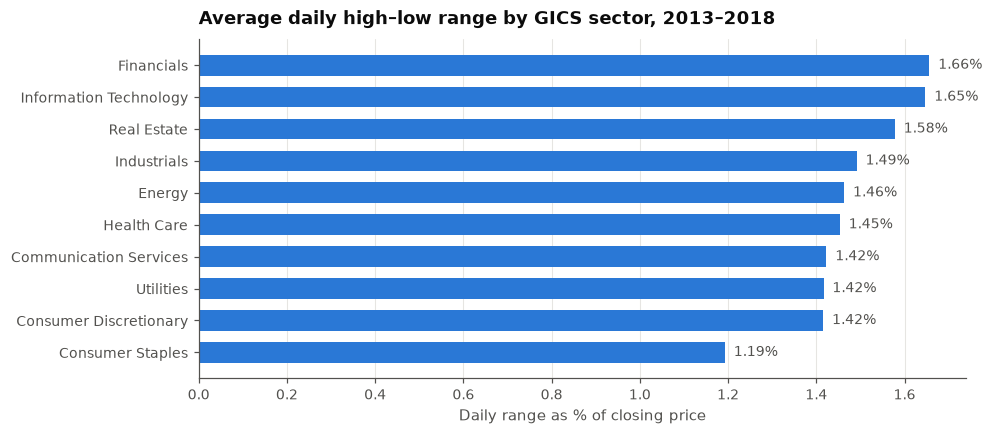

In [54]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_data = sector_stats["avg_daily_range_pct"].sort_values()
ax.barh(plot_data.index, plot_data.values, color="#2a78d6", height=0.65)
ax.set_title("Average daily high–low range by GICS sector, 2013–2018")
ax.set_xlabel("Daily range as % of closing price")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
for y, v in enumerate(plot_data.values):
    ax.text(v + 0.02, y, f"{v:.2f}%", va="center", fontsize=9, color="#52514e")
plt.show()

## 9. Missing data

Markets close. Stocks halt. Feeds arrive late. Companies delist. Your data
will have holes, and how you fill them changes your answer.

In [55]:
# The trading calendar is not the calendar calendar
all_days = pd.date_range(close_wide.index.min(), close_wide.index.max(), freq="D")
business_days = pd.date_range(close_wide.index.min(), close_wide.index.max(), freq="B")

print("Calendar days in the period: ", len(all_days))
print("Business days:               ", len(business_days))
print("Actual trading days in data: ", len(close_wide))
print("Difference (market holidays):", len(business_days) - len(close_wide))

Calendar days in the period:  1826
Business days:                1304
Actual trading days in data:  1259
Difference (market holidays): 45


In [56]:
# Reindexing onto every business day exposes the holidays as NaN
reindexed = close_wide.reindex(business_days)
print("Missing values introduced:", int(reindexed.isna().sum().sum()))

holidays = reindexed.index[reindexed["AAPL"].isna()]
print("\nFirst eight market holidays in the sample:")
for d in holidays[:8]:
    print("   ", d.date(), d.day_name())

Missing values introduced: 1350

First eight market holidays in the sample:
    2013-02-18 Monday
    2013-03-29 Friday
    2013-05-27 Monday
    2013-07-04 Thursday
    2013-09-02 Monday
    2013-11-28 Thursday
    2013-12-25 Wednesday
    2014-01-01 Wednesday


Three ways to deal with a hole, and they are not interchangeable:

| Method | What it does | When it is right |
|---|---|---|
| `.dropna()` | delete the row | the observation genuinely does not exist |
| `.ffill()` | carry the last price forward | a market holiday — the position still exists, the price just did not change |
| `.interpolate()` | straight-line between neighbours | almost never for prices; it invents a price that never traded |

**Forward fill is right for a holiday. Interpolation is not**, because it uses
tomorrow's price to fill in today — information you would not have had. That
is *look-ahead bias*, and it is the defect that makes most amateur backtests
worthless. Notebook 03 returns to this.

### A real example: Chevron, Thanksgiving 2014

US markets were closed on Thursday 27 November 2014. That same day, OPEC met
in Vienna and declined to cut production. When the market reopened on the
Friday, oil and the energy sector fell hard.

Look at what each filling method puts in the Thursday hole.

In [57]:
comparison = pd.DataFrame(
    {
        "raw": reindexed["CVX"],
        "ffill": reindexed["CVX"].ffill(),
        "interpolate": reindexed["CVX"].interpolate(),
    }
)
comparison.loc["2014-11-24":"2014-12-01"].round(2)

,raw,ffill,interpolate
2014-11-24,117.59,117.59,117.59
2014-11-25,116.15,116.15,116.15
2014-11-26,115.11,115.11,115.11
2014-11-27,NaN,115.11,111.99
2014-11-28,108.87,108.87,108.87
2014-12-01,111.73,111.73,111.73


Forward fill puts **115.11** in the Thursday hole — the last price that
actually traded, which is what a position would have been marked at.

Interpolation puts roughly **112** there, a number that is part-way to
Friday's post-OPEC price. Nobody could have known that on Thursday. If you
then computed a Thursday-to-Friday return from the interpolated series, your
model would appear to have anticipated the OPEC announcement — and your
backtest would show skill that does not exist.

### Exercise 3

Count how many trading days each ticker actually has in `close_wide`. Are
they all the same? What would a ticker with fewer days tell you about that
company's history?

*Hint:* `close_wide.notna().sum()`

In [62]:
# YOUR CODE HERE
Total = close_wide.notna().sum()
print(Total)
# A ticker with fewer days would show that the company IPO'd during the time that the dataset was created.

ticker
AAPL     1259
AMT      1259
BA       1259
BAC      1259
CAT      1259
CSCO     1259
CVX      1259
DIS      1259
DUK      1259
GE       1259
GOOGL    1259
GS       1259
HD       1259
INTC     1259
JNJ      1259
JPM      1259
KO       1259
MCD      1259
MMM      1259
MSFT     1259
NEE      1259
NKE      1259
PFE      1259
PG       1259
T        1259
UNH      1259
VZ       1259
WFC      1259
WMT      1259
XOM      1259
dtype: int64


## 10. Saving your work

Save the wide price matrix — Notebook 02 picks it up from here.

In [63]:
processed = REPO / "data" / "processed"
processed.mkdir(exist_ok=True)

close_wide.to_csv(processed / "close_wide.csv")
print("Wrote", processed / "close_wide.csv")
print(f"{close_wide.shape[0]} rows x {close_wide.shape[1]} columns")

Wrote /Users/sabrinaloftus/mtu4600-lab3-analytics/data/processed/close_wide.csv
1259 rows x 30 columns


---

## Recap

1. Parse dates on load, or nothing downstream works.
2. `describe()` before you model — it catches bad data cheaply.
3. `groupby` is split-apply-combine; it answers nearly every "by desk / by
   sector / by instrument" question.
4. Market data is stored long and analysed wide. `pivot` converts.
5. Check the row count after every `merge`.
6. Forward-fill holidays. Do not interpolate prices.

## Your turn

Complete the three exercises above, then commit and push:

```
git add notebooks/01_pandas_fundamentals.ipynb
git commit -m "Completed notebook 01 exercises"
git push
```

Next: `02_returns_and_risk.ipynb`